In [106]:
print("hello world")
df_groh["DIAGPRINCIPAL_final.recod"].str.lower().value_counts().sum()

hello world


np.int64(2385)

In [111]:
df_groh["DIAGPRINCIPAL_final.recod"].str.lower()

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
4133    NaN
4134    NaN
4135    NaN
4136    NaN
4137    NaN
Name: DIAGPRINCIPAL_final.recod, Length: 4138, dtype: object

In [99]:
import sys
sys.modules.pop('feature_transformer', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)

<module 'utils.algo_prediction' from 'c:\\Users\\romai\\Desktop\\codes\\respiratory_diagnostics\\utils\\algo_prediction.py'>

In [100]:
from utils.feature_loader import load_feature_lists
from utils.data_quality import nettoyer_nan_par_colonne
# from utils.data_quality import nettoyer_lignes_vides
import pandas as pd
df_groh = pd.read_excel(r"C:\Users\romai\Desktop\travail\Copie de BAZEA.xlsx")
# taux de Nan
# for col in df_groh.columns:
#     print(round(df_groh[col].isna().mean(),2),col, )
# df_groh,index_a_drop = nettoyer_lignes_vides(df_groh)
feature_lists = load_feature_lists("utils/features_grroh.json",available_columns = df_groh.columns)
features_grroh = df_groh[feature_lists["Liste_features_grroh"] + feature_lists["Liste_features_scan_radio"]]
features_etiology = df_groh[feature_lists["features_etiology"]]
features_death = df_groh[feature_lists["death"]]
# print(features_grroh.columns)


In [79]:
from utils.data_quality import nettoyer_lignes_vides
from utils.feature_transformer import transform_features
sys.modules.pop('utils.utils_grroh',None)
from utils.utils_grroh import construire_mapping_renommage,format_to_efraim,ensure_float_clip
feature_lists = load_feature_lists("utils/features_grroh.json",available_columns = df_groh.columns)

features_grroh = df_groh[feature_lists["Liste_features_grroh"] + feature_lists["Liste_features_scan_radio"]+ feature_lists["features_etiology"] ]
mapping_df = construire_mapping_renommage(feature_lists["Liste_features_grroh"] +feature_lists["Liste_features_scan_radio"] + feature_lists["features_etiology"] )
df_renomme = format_to_efraim(features_grroh, mapping_df)
df_renomme = ensure_float_clip(df_renomme)
df_nb = df_renomme.select_dtypes(include="number")
# _ = df_nb.hist(figsize=(10,8))
L_fill_mediane = ["Age"	,
                  "Time H-ICU"	,
                  "TIME SYMPTOMES-ICU",
                  "Time  DG-ICU",
                  "SOFA_score",
                  "Temp",
                  "Charlson_index",
                  "SaO2",
                  "PaO2/FiO2 VALUE VALUE",
                  "Resp_rate",
                  "Leukocytes",
                  "Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in df_renomme.columns
}
grroh_clean = nettoyer_nan_par_colonne(df_renomme,strategie_fill_nan)
grroh_clean["Hem_mal"]  = grroh_clean["Hem_mal"] .fillna(0)
grroh_clean_transform = transform_features(grroh_clean)
grroh_clean_transform = grroh_clean_transform.drop(columns=['Leukocytes'])
# Enlever les non diag
L_diag = ['Bacterial infection', 'Viral infection',
'Invasive pulmonary aspergillosis', 'All fungus', 'Other fungal',
'Mucorales', 'Pneumocystis jirovecii infection',
'Cardiogenic pulmonary oedema', 'Disease-related infiltrates',
'Drug toxicity related', 'Other infection',
'Other non infectious causes']
grroh_diag = grroh_clean_transform[L_diag]

# grroh_diag,index_a_drop = nettoyer_lignes_vides(grroh_diag)
# grroh_features = grroh_clean_transform.drop(index=index_a_drop)

🔹 Age → NaN remplacés par la médiane (63.0)
🔹 Time H-ICU → NaN remplacés par la médiane (6.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (1.0)
🔹 Time  DG-ICU → NaN remplacés par la médiane (199.0)
🔹 Charlson_index → NaN remplacés par la médiane (5.0)
🔹 SOFA_score → NaN remplacés par la médiane (6.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 SaO2 → NaN remplacés par la médiane (0.92)
🔹 Temp → NaN remplacés par la médiane (38.1)
🔹 Leukocytes → NaN remplacés par la médiane (8.2)
🔹 Quad_no → NaN remplacés par la médiane (2.0)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (149.0)

✅ Nettoyage terminé. NaN restants : 0


In [81]:
grroh_diag.head()

,Bacterial infection,Viral infection,Invasive pulmonary aspergillosis,All fungus,Other fungal,Mucorales,Pneumocystis jirovecii infection,Cardiogenic pulmonary oedema,Disease-related infiltrates,Drug toxicity related,Other infection,Other non infectious causes
0,False,False,False,False,False,0,False,False,False,False,False,False
1,False,False,False,False,False,0,False,False,False,False,False,False
2,False,False,False,False,False,0,False,False,False,False,False,True
3,False,False,False,False,False,0,False,False,True,False,False,False
4,False,False,False,False,False,0,False,False,False,False,False,False


In [83]:
nettoyer_lignes_vides(grroh_diag.head())

Nombre de lignes totalement vides : 3


(   Bacterial infection  Viral infection  Invasive pulmonary aspergillosis  \
 2                False            False                             False   
 3                False            False                             False   
 
    All fungus  Other fungal  Mucorales  Pneumocystis jirovecii infection  \
 2       False         False          0                             False   
 3       False         False          0                             False   
 
    Cardiogenic pulmonary oedema  Disease-related infiltrates  \
 2                         False                        False   
 3                         False                         True   
 
    Drug toxicity related  Other infection  Other non infectious causes  
 2                  False            False                         True  
 3                  False            False                        False  ,
 [0, 1, 4])

In [ ]:

df_cat_clean,index_a_drop = nettoyer_lignes_vides(df_category)
df_features_clean = df_features_clean.drop(index=index_a_drop)

<Axes: >

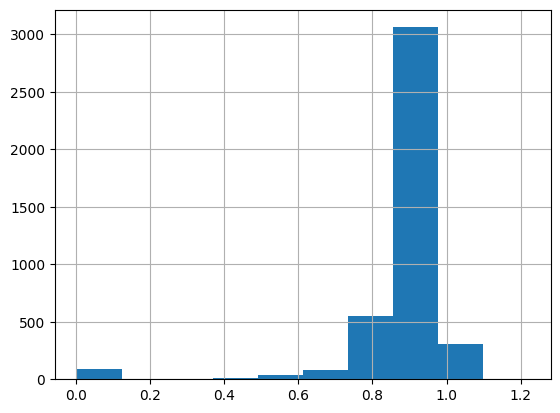

In [ ]:
df_groh[df_groh["PAO2FIO2_meca"]>0]
df_float = ensure_float_clip(df_groh)
grroh_clean_transform["SaO2"].hist()

In [6]:
grroh_clean_transform
grroh_clean_transform[grroh_clean_transform["PaO2/FiO2 VALUE VALUE"]>0]

,Time H-ICU,TIME SYMPTOMES-ICU,Time DG-ICU,HSCT_BMT_Allograft,HSCT_BMT_Autograft,Sys_dis,Solid_tumor,Organ_transpl,Immuno_drugs,Steroids_YN,...,Hem_mal_CML,Hem_mal_MDS,Hem_mal_other,SOFA_scaled,Resp_severity,Temp_gravité,Leukostase,Indication_prophy_anti_fun,Indication_prophy_pneumocystose_taken,Indication_prophy_pneumocystose_not_taken
0,0.933333,0.666667,0.941176,0.0,0.0,0,0,0,False,0.0,...,0,0,0,0.416667,0.0,0.6,False,1.0,False,False
1,0.923077,0.000000,0.500000,0.0,0.0,0,0,0,False,0.0,...,0,0,0,0.375000,0.0,0.6,False,0.0,True,False
3,0.000000,0.900000,0.000000,0.0,0.0,0,0,0,False,1.0,...,0,0,0,0.125000,0.0,0.6,True,1.0,False,True
5,0.981132,0.000000,0.956522,0.0,0.0,0,0,0,False,1.0,...,0,0,0,0.458333,1.0,0.2,False,0.0,False,True
6,0.983051,0.000000,0.983051,0.0,0.0,0,0,0,False,1.0,...,0,0,0,0.125000,1.0,0.6,False,0.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2062,0.000000,0.666667,0.997260,0.0,0.0,0,0,0,False,0.0,...,0,0,1,0.166667,0.0,0.0,False,0.0,False,False
2063,0.000000,1.250000,0.997260,0.0,0.0,0,0,1,True,0.0,...,0,0,0,0.208333,0.0,0.6,False,0.0,False,True
2064,0.000000,0.000000,0.977778,0.0,0.0,0,1,0,False,0.0,...,0,0,0,0.250000,0.0,0.0,False,0.0,False,False
2065,0.000000,0.800000,0.997260,0.0,0.0,0,0,1,True,1.0,...,0,0,0,0.291667,0.0,0.0,False,0.0,False,True


In [29]:
df_bool = df_renomme.select_dtypes(include="bool")
print(df_bool.mean())

GvHD                                0.000483
Ibr_Flu_Met                         0.003383
Sex                                 0.379410
Chemotherapy                        0.265104
Bacterial infection                 0.108990
Viral infection                     0.024166
Invasive pulmonary aspergillosis    0.005075
All fungus                          0.020300
Other fungal                        0.000967
Pneumocystis jirovecii infection    0.019333
Cardiogenic pulmonary oedema        0.032866
Disease-related infiltrates         0.023200
Drug toxicity related               0.007733
Other infection                     0.017641
Other non infectious causes         0.017883
dtype: float64


# Efraim 

In [61]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt
from utils.stats_dataset import analyser_variables_binaires
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_loader import load_feature_lists, load_diagnostic_feature_map
import sys
# loads the col
FEATURE_CONFIG_PATH = "utils/feature_columns.json"
feature_lists = load_feature_lists(FEATURE_CONFIG_PATH)
Liste_features_simple = feature_lists["Liste_features_simple"]
features_radiology_dysfunction = feature_lists["features_radiology_dysfunction"]
features_etiology = feature_lists["features_etiology"]
features_death = feature_lists["death"]
# Charger le fichier Excel
df = pd.read_excel(r"C:\Users\romai\Desktop\travail\EFRAIM3 JD VANCE.xlsx")

# separer colonnes explicatives et etiology
df = df[df['Etiology_Undetermined cause_Definitive diagnosis'] != 1]
features_etiology.remove('Etiology_Undetermined cause_Definitive diagnosis')

diagnostic_feature_map = load_diagnostic_feature_map(
    FEATURE_CONFIG_PATH,
    available_columns=df.columns,
    diagnoses = ["default"] #"Bacterial infection", # A changer pour bacterial !!! 
)
all_feature_columns = []
for columns_list in diagnostic_feature_map.values():
    for feature_name in columns_list:
        if feature_name not in all_feature_columns:
            all_feature_columns.append(feature_name)
Liste_features = all_feature_columns
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
df_death = df[features_death]
DIAGNOSTIC_FEATURES = diagnostic_feature_map
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","SOFA_Nervous","SOFA_Nervous",
                  "Neutrophils","Temp","SpO2","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no","Charlson_index"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
strategie_fill_nan["DG1"] = "str"
strategie_fill_nan["DG2"] = "str"
strategie_fill_nan["Sys_dis_spec"] = "str"
df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
# resultats = analyser_nan(df_col_utils, top_n=3)
# resultats_y = analyser_nan(df_category, top_n=8)
df_category = nettoyer_colonnes(df_category)
df_cat_clean,index_a_drop = nettoyer_lignes_vides(df_category)
df_features_clean = df_features_clean.drop(index=index_a_drop)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)
# format mapping_etiology[nvelle_col] = [old_col1,old_cold2 ,...]
mapping_etiology ={
                    'Bacterial infection' :['Bacterial infection'] ,
                    'Viral infection' :['Viral infection'] ,
                    'Invasive pulmonary aspergillosis' :['Invasive pulmonary aspergillosis'] ,
                    'All fungus' : ["Other fungal ",'Mucorales'],
                    'Other fungal' :["Other fungal "] ,
                    'Mucorales' : ['Mucorales'],
                    'Pneumocystis jirovecii infection' :[ 'Pneumocystis jirovecii infection'],
                    'Cardiogenic pulmonary oedema' : ['Cardiogenic pulmonary oedema'],
                    'Disease-related infiltrates':['Disease-related infiltrates'],
                    'Drug toxicity related' : ['Drug toxicity related'],
                    'Other infection' : ['Other infection '],
                    'Other non infectious causes': ['Other non infectious causes','Transfusion-related acute lung injury'],
                   # 'Undetermined cause':['Undetermined cause' ]
                    }
from utils.data_quality import fusionner_labels
df_labels_fusion = fusionner_labels(df_cat_clean, mapping_etiology, mode="max")


🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 Charlson_index → NaN remplacés par la médiane (5.0)
🔹 SOFA_Nervous → NaN remplacés par la médiane (0.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 SpO2 → NaN remplacés par la médiane (92.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (88.0)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)
🔹 Quad_no → NaN remplacés par la médiane (3.0)
⚠️ Colonne 'DG1' absente du DataFrame, ignorée.
⚠️ Colonne 'DG2' absente du DataFrame, ignorée.
⚠️ Colonne 'Sys_dis_spec' absente du DataFrame, ignorée.

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 3055


# Comparasion des valeurs 

In [58]:
sys.modules.pop('utils.data_quality',None)
from utils.data_quality import compare_columns
df_with_diag = pd.concat([df_features_clean,df_labels_fusion],axis=1)

compare_columns(df_with_diag,grroh_clean_transform)

Colonnes uniquement dans df1 :
set()

Colonnes uniquement dans df2 :
set()


In [59]:
grroh_clean_transform["SaO2"]

0       0.97
1       0.95
2       0.99
3       0.98
4       0.97
        ... 
4133    0.94
4134    0.94
4135    0.98
4136    0.97
4137    0.92
Name: SaO2, Length: 4138, dtype: float64

[HSCT_BMT_Allograft] difference d'occurrence >= 5.0 pts
    valeur=np.float64(0.0): 5777/6360 (90.83%) vs 3540/4138 (85.55%) -> diff +5.28 pts (5.8% de la valeur max 90.83%)
    valeur=np.float64(1.0): 583/6360 (9.17%) vs 440/4138 (10.63%) -> diff -1.47 pts (13.8% de la valeur max 10.63%)
[HSCT_BMT_Autograft] difference d'occurrence >= 5.0 pts
    valeur=np.float64(0.0): 6081/6360 (95.61%) vs 1582/4138 (38.23%) -> diff +57.38 pts (60.0% de la valeur max 95.61%)
    valeur=np.float64(1.0): 279/6360 (4.39%) vs 244/4138 (5.90%) -> diff -1.51 pts (25.6% de la valeur max 5.90%)
[Sys_dis] difference d'occurrence >= 5.0 pts
    valeur=np.int64(0): 5239/6360 (82.37%) vs 3824/4138 (92.41%) -> diff -10.04 pts (10.9% de la valeur max 92.41%)
    valeur=np.int64(1): 1121/6360 (17.63%) vs 314/4138 (7.59%) -> diff +10.04 pts (56.9% de la valeur max 17.63%)
[Solid_tumor] difference d'occurrence >= 5.0 pts
    valeur=np.int64(0): 3950/6360 (62.11%) vs 3069/4138 (74.17%) -> diff -12.06 pts (16.3% de la

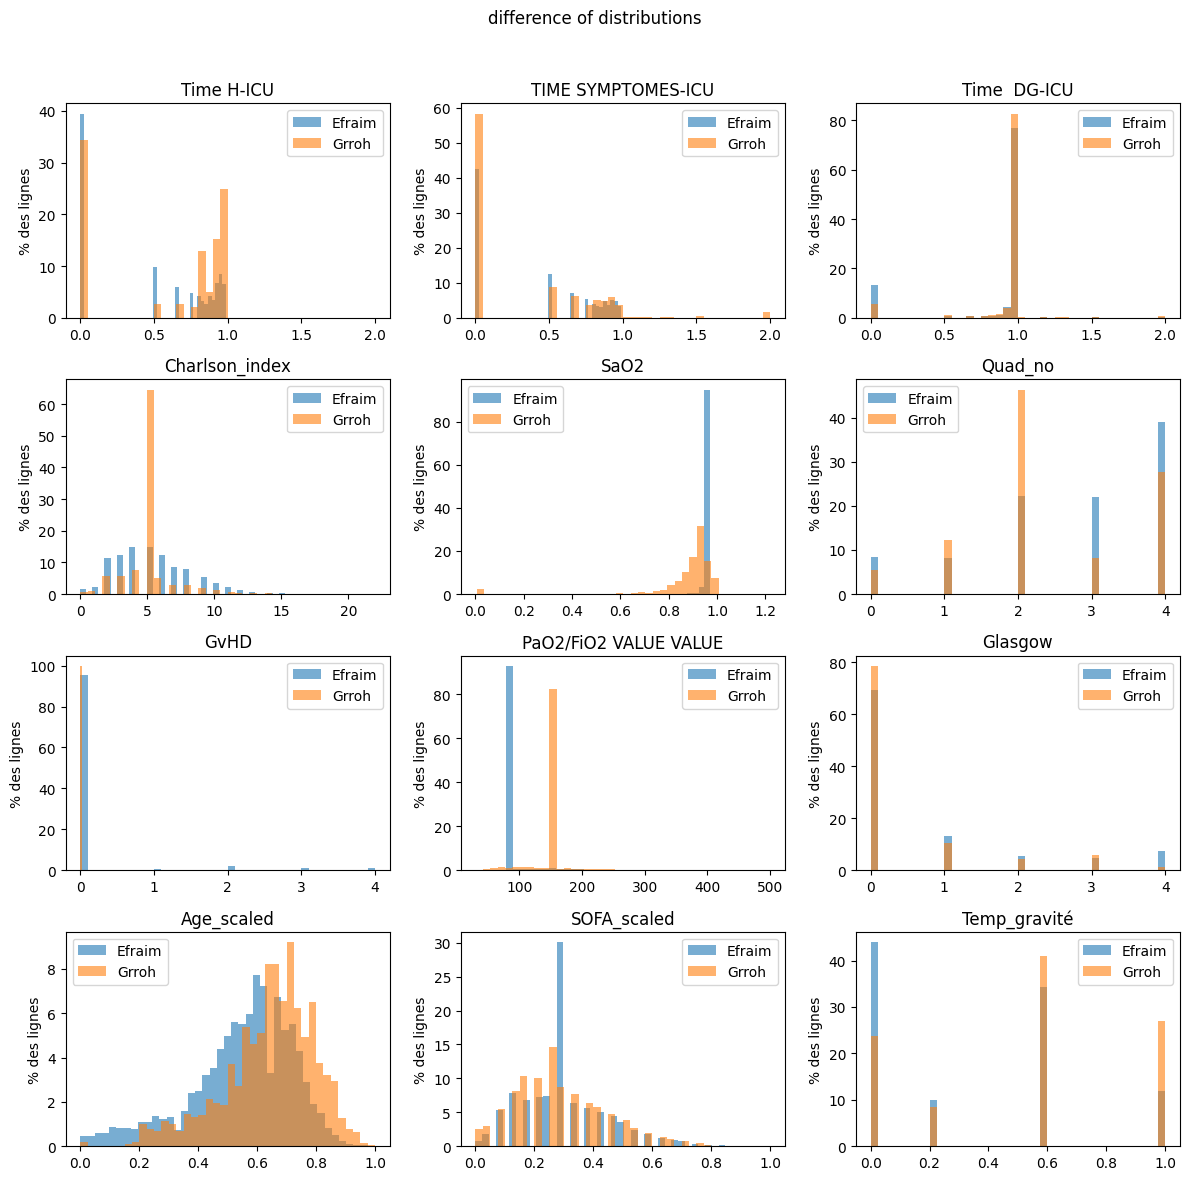

In [60]:
sys.modules.pop("utils.data_quality",None)
from utils.data_quality import plot_column_histograms

fig, axes = plot_column_histograms(
    df_left=df_with_diag,
    df_right=grroh_clean_transform,
    columns=grroh_clean_transform.columns,
    bins=40,
    label_left="Efraim",
    label_right="Grroh",
    suptitle="difference of distributions"
)
plt.show()

# performance sur les données du grroh

In [84]:
from utils.model_saving import save_model, load_model
import os 
loaded = load_model(diagnostic ='Bacterial infection',
                   model_dir = os.getcwd() + r'\models\\'
                   )
pipe_inference = loaded["pipe_inference"]

In [ ]:
for x in L_diag:
    print(x)


Bacterial infection
Viral infection
Invasive pulmonary aspergillosis
All fungus
Other fungal
Mucorales
Pneumocystis jirovecii infection
Cardiogenic pulmonary oedema
Disease-related infiltrates
Drug toxicity related
Other infection
Other non infectious causes


In [95]:
for x in df_groh["DIAGPRINCIPAL_final.recod"].value_counts().index:
    try:
        float(x) 
        
    except:
        print(x)

BACT
BACT DOCU
UNDETERMINED
bact
EXTRA
UNKNOWN
infiltratif
BACT CLI
INFLUENZA
PCP
OAP
extra
INFILTRATIF
unknown
oap
aspiration
VIRUS
candidemie
AIRWAYS
airways
ASPIRATION
pcp
PLEURA
tox
pleura
TOX
IPA
influenza
ipa
copd
AUTRE
API
vrs
EP
pe
DRPT
VRS
RHINOVIRUS
PE
CMV
COPD
METAPNEUMOVIRUS
CORONAVIRUS
cmv
PIV3
parasite
ADENOVIRUS
bk
TRICHOSPORON
piv3
BACT DOCU + CAND
ENTEROVIRUS
MUCOR
NEUT RECOV
HSV
INFLuenza
coronavirus
rhinovirus
trichosporon


In [ ]:

y_test_array = np.asarray(y_test)
proba_raw = pipe_inference.predict_proba(X_test)
metrics = get_metric()
from utils.models_and_metrics import  get_metric
metric_scores = {}
for metric_name, metric_info in metrics.items():

    preds_input = proba_raw
    metric_scores[metric_name] = metric_info["metric_fn"](y_test_array, preds_input)
    metric_scores

# Graphique de nom de maladie du sang

NameError: name 'plt' is not defined

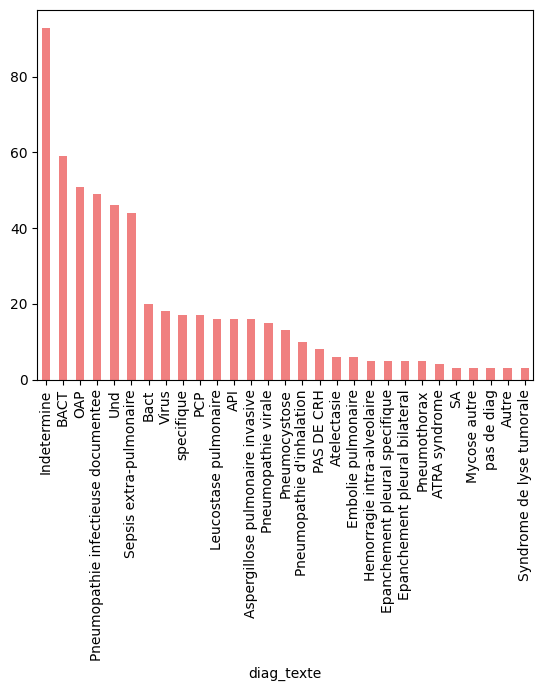

In [ ]:
df["diag_texte"].value_counts()[1:30].plot(kind='bar', color='lightcoral')
import matplotlib.pyplot as plt
plt.title("Distribution des diagnostiques")
plt.xlabel("diagnostiques")
plt.ylabel("Occurence")
plt.xticks(rotation=45, ha='right')
plt.show()